# Behavioral sessions

In [1]:
from multimodal_analysis.db import get_schema_modules, get_schemas

exp, stim, beh, inter, rec, mice = get_schema_modules()

from multimodal_analysis.config import (
    add_behavior_sessions,
    get_behavior_sessions,
    remove_behavior_sessions,
    create_analysis_key
)

from multimodal_analysis.plots import (
    # distribution.py
    get_condition_distribution_data,
    plot_condition_trial_distribution,
    plot_condition_distribution_percentage,
    get_object_distribution_trials, highlight_object_trials_distribution_table,
    # modality.py
    get_linePlot_per_modality_across_sessions,
    get_scatter_plot_modalities,
    # multimodal_trials.py
    get_multimodal_performance_summary,
    plot_multimodal_performance_per_object,
    # responses.py
    calculate_response_type,
    plot_response_counts,
    # visual_trials.py
    get_visual_performance_summary,
    plot_visual_performance_per_object
)

Please enter DataJoint username:  eflab
Please enter DataJoint password:  ········


[2026-10-09 16:15:28,200][INFO]: Connecting eflab@database.eflab.org:3306
[2026-10-09 16:15:28,231][INFO]: Connected eflab@database.eflab.org:3306


## Management of sessions

Behavioral sessions are stored in `beh_sessions.json` in the `config/` directory.

The JSON is organized hierarchically by **animal ID → task type → session IDs**.

**Available `task_types`:** *visual*, *audiovisual*, *audiovisual_diff*, *audiovisual_no_stim*, *audiovisual_obj215*, and *audiovisual_conflicted*.


In [ ]:
# Define the animal, task type, and session IDs to add.
animal_id = 299
task_type = "audiovisual_conflicted"
sessions = [681]

In [ ]:
# Add the sessions to the behavioral session configuration.
add_behavior_sessions(animal_id=animal_id, task_type=task_type, sessions=sessions)

In [ ]:
# Retrieve and verify the sessions currently assigned
# to this animal and task type.
get_behavior_sessions(animal_id=animal_id, task_type=task_type)

In [ ]:
# Remove sessions from an animal and task type.
# Add the session IDs to the list below when removal is needed.
remove_behavior_sessions(animal_id=0, task_type="visual", sessions=[20,21])

## Quick Overview of Sessions

In [2]:
# Define the animal and behavioral task for the analysis
# Set animal_id to None to include all animals
# Available task types: "visual", "audiovisual", "audiovisual_diff", "audiovisual_no_stim", 
# "audiovisual_obj215", "audiovisual_conflicted"
animal_id = 299
task_type = "audiovisual"

# Define the difficulty levels and sessions to exclude.
difficulties = [2]
excluded_sessions = []

In [3]:
# Get the behavioral sessions available for the selected animal and task.
sessions_idx = get_behavior_sessions(animal_id=animal_id, task_type=task_type)
print("sessions_idx: \n", sessions_idx)

# Define the first session to include in the analysis.
from_session = get_behavior_sessions(animal_id=animal_id, task_type=task_type)[50]
print("\nfrom_session:", from_session)

# Define the last session to include in the analysis.
to_session = get_behavior_sessions(animal_id=animal_id, task_type=task_type)[-1]
print("to_session:", to_session)

# Calculate the total number of sessions included in the analysis.
total_sessions = len(sessions_idx[31:])
print("total_sessions:", total_sessions)

sessions_idx: 
 [100, 103, 107, 111, 113, 117, 119, 121, 123, 125, 129, 131, 133, 135, 137, 139, 194, 196, 197, 198, 199, 200, 202, 203, 204, 205, 206, 207, 210, 211, 213, 323, 324, 326, 331, 333, 334, 335, 336, 337, 338, 340, 341, 342, 343, 346, 352, 359, 360, 361, 362, 363, 374, 376, 379, 380, 381, 383, 385, 386, 388, 390, 465, 473, 474, 475, 486, 488, 489, 490, 491, 492, 493, 478, 481, 486, 488, 489, 490, 491, 492, 493, 578, 583, 584, 585, 586, 589, 590, 593, 595, 596, 597, 598, 600, 601, 603, 604, 605, 606, 607, 608, 609, 611, 615, 624, 626, 627, 631, 633]

from_session: 362
to_session: 633
total_sessions: 79


In [4]:
# Create the analysis configuration for the selected animal and sessions.
# Parameters:
# animal_id (int): Animal ID.
# from_session (int): First session.
# to_session (int): Last session.
# difficulties (list): Difficulty levels to include.
# excluded_sessions (list): Sessions to exclude.
key = create_analysis_key(
    animal_id, from_session, to_session, difficulties, excluded_sessions
)

<Axes: title={'center': 'Animal 299'}, xlabel='Session', ylabel='Number of trials'>

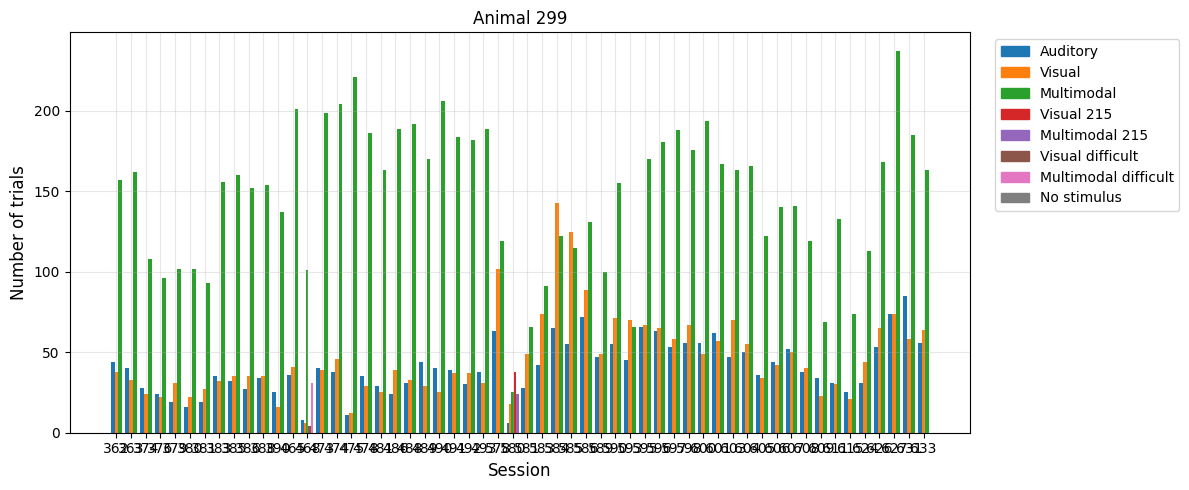

In [5]:
# Distribution of trial counts for each trial type across sessions.
# Parameters:
# key (dict): animal_id, from_session, to_session, difficulties, excluded_sessions
# incl_aborts (bool): Whether to include aborted trials.
plot_condition_trial_distribution(key, stim, exp, incl_aborts=False)

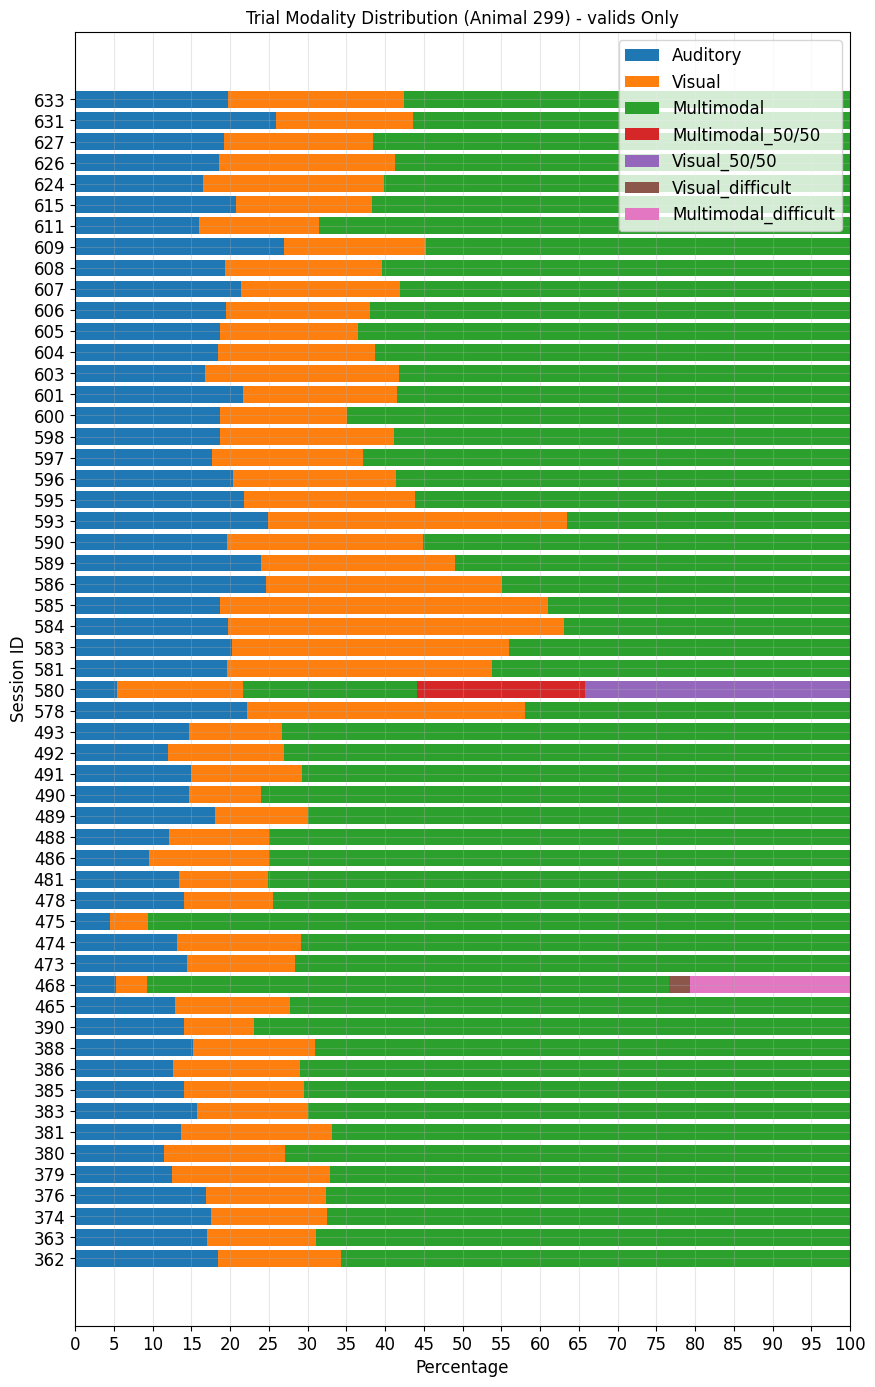

In [6]:
# Distribution of each trial type across sessions in percentage
# Parameters:
# key (dict): animal_id, from_session, to_session, difficulties, excluded_sessions
# incl_aborts (bool): Whether to include aborted trials.
plot_condition_distribution_percentage(key, stim, exp, incl_aborts=False)

In [7]:
# Trial distribution dataframe of each object across sessions
# Parameters:
# key (dict): animal_id, from_session, to_session, difficulties, excluded_sessions
# incl_aborts (bool): Whether to include aborted trials.
# Returns:
# Formatted DataFrame with highlighted object trial counts:
#   - Light green: Trials are present in both visual and audiovisual modalities.
#   - Orange: Trials are present in only one modality.
#   - No color: No trials are present in either modality (0 / 0).
get_object_distribution_trials(key, stim, exp, incl_aborts=False).style.map(
    highlight_object_trials_distribution_table
)

,session,obj212,obj213,obj215,obj217,obj218,obj219
0,362,10 / 32,11 / 35,0 / 0,0 / 0,12 / 41,5 / 49
1,363,9 / 44,7 / 29,0 / 0,0 / 0,9 / 46,8 / 43
2,374,5 / 22,10 / 18,0 / 0,0 / 0,6 / 33,3 / 35
3,376,3 / 15,8 / 26,0 / 0,0 / 0,5 / 25,6 / 30
4,379,10 / 23,10 / 28,0 / 0,0 / 0,5 / 24,6 / 27
5,380,6 / 23,4 / 22,0 / 0,0 / 0,6 / 28,6 / 29
6,381,6 / 22,6 / 19,0 / 0,0 / 0,12 / 28,3 / 24
7,383,14 / 27,3 / 36,0 / 0,0 / 0,9 / 52,6 / 41
8,385,13 / 36,12 / 34,0 / 0,0 / 0,8 / 44,2 / 46
9,386,5 / 32,12 / 35,0 / 0,0 / 0,9 / 40,9 / 45
